In [1]:
import numpy as np

from easydynamics.sample import Gaussian
from easydynamics.sample import Lorentzian
from easydynamics.sample import DampedHarmonicOscillator
from easydynamics.sample import Polynomial
from easydynamics.sample import SampleModel

import matplotlib.pyplot as plt

import scipp as sc

from easydynamics.utils import detailed_balance_factor

%matplotlib widget

In [2]:
# Creating a component
gaussian=Gaussian(name='Gaussian',center=0,width=0.5,area=1)
gaussian

Gaussian(name=Gaussian, area=<Parameter 'Gaussian area': 1.0000 meV, bounds=[-inf:inf]>, center=<Parameter 'Gaussian center': 0.0000 meV, bounds=[-inf:inf]>, width=<Parameter 'Gaussian width': 0.5000 meV, bounds=[0.0:inf]>)

C:\Users\henrikjacobsen3\Documents\easyScience\dynamics-lib\src\easydynamics\sample\components.py:766: UserWarning: The polynomial with name BG has negative values, which may not be physically meaningful.
  warnings.warn("The polynomial with name {} has negative values, which may not be physically meaningful.".format(self.name))


Text(0, 0.5, 'y')

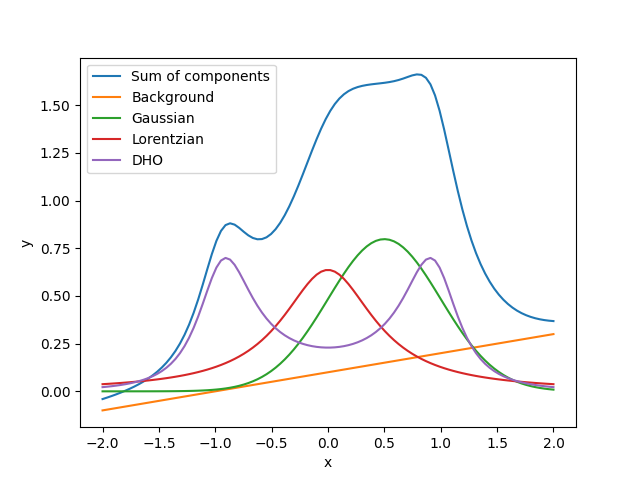

In [3]:
# Creating a sample model with multiple components
sample= SampleModel(name='MySampleModel')
sample.add_component(Gaussian(name='Gaussian',center=0.5,width=0.5,area=1))
sample.add_component(Lorentzian(name='Lorentzian',center=0, width=0.5, area=1))
sample.add_component(Polynomial(name='BG',coefficients=[0.1, 0.1]))
sample.add_component(DampedHarmonicOscillator(name='DHO',center=1, width=0.3, area=1.2))

x=np.linspace(-2, 2, 100)
y=sample.evaluate(x)
plt.plot(x, y, label='Sum of components')
plt.plot(x, sample.evaluate_component('BG',x), label='Background')
plt.plot(x, sample.evaluate_component('Gaussian',x), label='Gaussian')
plt.plot(x, sample.evaluate_component('Lorentzian',x), label='Lorentzian')
plt.plot(x, sample.evaluate_component('DHO',x), label='DHO')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')


In [4]:
# The area under the DHO curve is indeed equal to the area parameter.
xx=np.linspace(-10, 10, 10000)
yy=sample.evaluate_component('DHO',xx)
area= np.trapezoid(yy, xx)
print(f"Area under DHO curve: {area:.4f}")


Area under DHO curve: 1.1998


C:\Users\henrikjacobsen3\Documents\easyScience\dynamics-lib\src\easydynamics\sample\components.py:213: UserWarning: Input x has unit meV, but Gaussian component has unit eV. Converting Gaussian to meV.
  warnings.warn(f"Input x has unit {x.unit}, but Gaussian component has unit {self.unit}. Converting Gaussian to {x.unit}.")
C:\Users\henrikjacobsen3\Documents\easyScience\dynamics-lib\src\easydynamics\sample\components.py:336: UserWarning: Input x has unit meV, but Lorentzian component has unit microeV. Converting Lorentzian to meV.
  warnings.warn(f"Input x has unit {x.unit}, but Lorentzian component has unit {self.unit}. Converting Lorentzian to {x.unit}.")


Text(0, 0.5, 'y (arb. unit)')

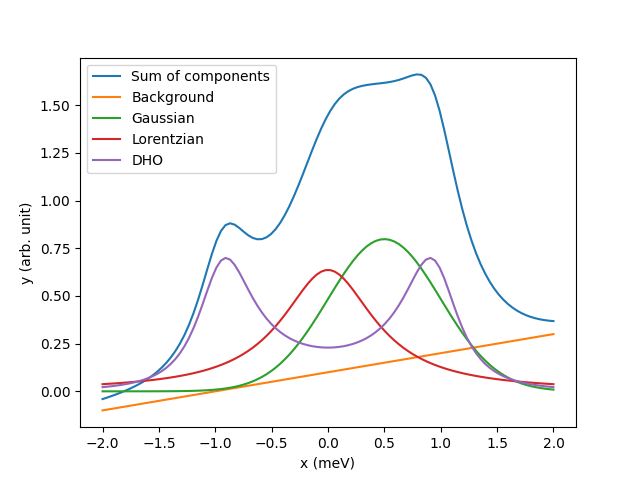

In [5]:
# Creating a sample model with multiple components with different units
sample= SampleModel(name='MySampleModel')
sample.add_component(Gaussian(name='Gaussian',center=0.5*1e-3,width=0.5*1e-3,area=1*1e-3,unit='eV'))
sample.add_component(Lorentzian(name='Lorentzian',center=0, width=500, area=1000,unit='microeV'))
sample.add_component(Polynomial(name='BG',coefficients=[0.1, 0.1],unit='meV'))
sample.add_component(DampedHarmonicOscillator(name='DHO',center=1, width=0.3, area=1.2,unit='meV'))

# y = sc.linspace('y', 0.0, 1.0, num=4, unit='m')
x=sc.linspace('x',-2, 2, num=100,unit='meV')
y=sample.evaluate(x)
plt.figure()
plt.plot(x, y, label='Sum of components')
plt.plot(x, sample.evaluate_component('BG',x), label='Background')
plt.plot(x, sample.evaluate_component('Gaussian',x), label='Gaussian')
plt.plot(x, sample.evaluate_component('Lorentzian',x), label='Lorentzian')
plt.plot(x, sample.evaluate_component('DHO',x), label='DHO')
plt.legend()
plt.xlabel('x (meV)')
plt.ylabel('y (arb. unit)')


Text(0.5, 1.0, 'Detailed Balance Factor with division by T')

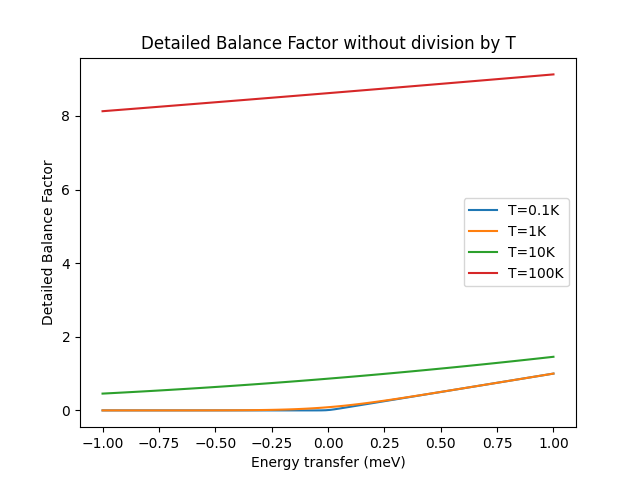

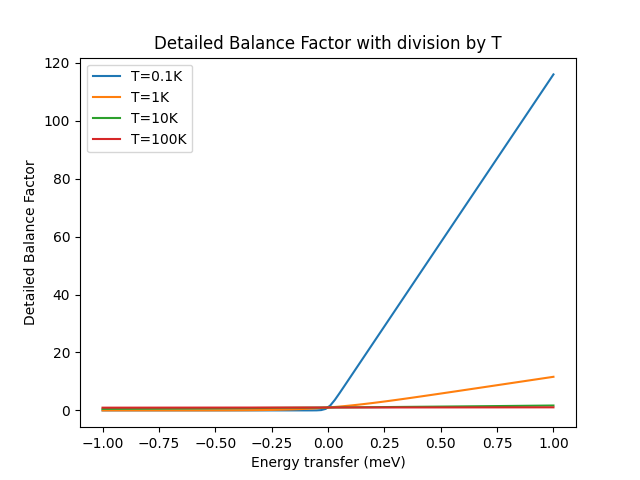

In [6]:


temperatures=[0.1, 1, 10, 100]
temperature_unit='K'
omega=np.linspace(-1,1,100)
# omega=1.0
omega_unit='meV'

plt.figure()
for temperature in temperatures:
    DBF = detailed_balance_factor(omega, temperature, omega_unit,temperature_unit)
    plt.plot(omega, DBF, label=f'T={temperature}K')
plt.legend()
plt.xlabel('Energy transfer (meV)')
plt.ylabel('Detailed Balance Factor')
plt.title('Detailed Balance Factor without division by T')


plt.figure()
for temperature in temperatures:
    DBF = detailed_balance_factor(omega, temperature, omega_unit,temperature_unit, divide_by_T=True)
    plt.plot(omega, DBF, label=f'T={temperature}K')
plt.legend()
plt.xlabel('Energy transfer (meV)')
plt.ylabel('Detailed Balance Factor')
plt.title('Detailed Balance Factor with division by T')


Text(0.5, 1.0, 'Sample model with detailed balance (divided by T)')

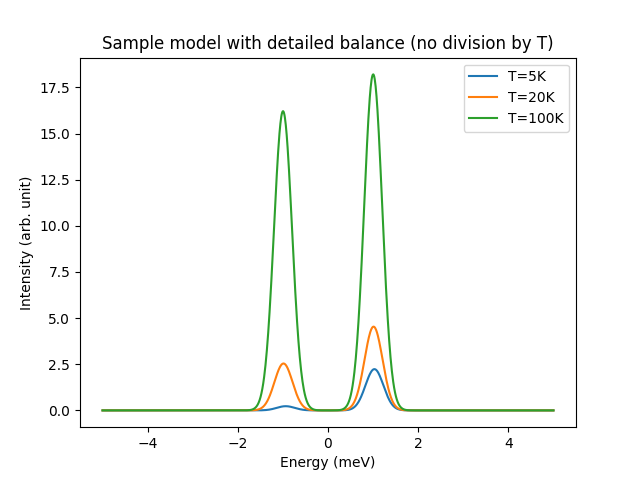

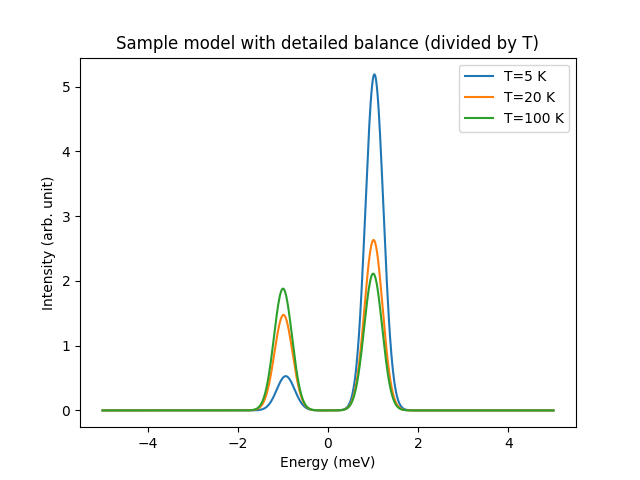

In [12]:
# Creating a sample model with multiple components and temperature
sample= SampleModel(name='MySampleModel')
sample.add_component(Gaussian(name='Gaussian',center=1,width=0.2,area=1))
sample.add_component(Gaussian(name='Gaussian2',center=-1, width=0.2, area=1))
sample.detailed_balance_divide_by_T = False
temperatures = [5, 20, 100]
plt.figure()
for T in temperatures:
    sample.temperature = T
    x=np.linspace(-5, 5, 1000)
    y=sample.evaluate(x)
    plt.plot(x, y, label=f'T={T}K')
plt.legend()

plt.xlabel('Energy (meV)')
plt.ylabel('Intensity (arb. unit)')
plt.title('Sample model with detailed balance (no division by T)')

sample.detailed_balance_divide_by_T = True
plt.figure()
for T in temperatures:
    sample.temperature = T
    x=np.linspace(-5, 5, 1000)
    y=sample.evaluate(x)
    plt.plot(x, y, label=f'T={T} K')
plt.legend()

plt.xlabel('Energy (meV)')
plt.ylabel('Intensity (arb. unit)')
plt.title('Sample model with detailed balance (divided by T)')
